# Texturing

Implements the paper's Section 2.4.6, following on from [meshing.ipynb](meshing.ipynb):

> The texturing process refers back to the original sets of photographs and the camera
> position information calculated during the sparse point-cloud reconstruction to determine
> the detailed appearance (i.e., texture) of each face of the mesh. ... This is a more complex
> task than in the conventional single-scan photogrammetry workflow because the merging
> process will have reoriented the component parts of the mesh, requiring the camera positions
> to be moved accordingly. The starting point of the process is the set of camera locations
> estimated by the bundle adjustment processing of VisualSFM ... As a result of the point
> cloud registration stage, each of the N partial meshes has been transformed from the
> location assumed by the bundle adjustment process. As a result, before texturing, the mesh
> must also be transformed by a model-matrix, Mn ...

This replica repositions Step 4's calibrated real cameras into Step 8's mesh's common frame
(this replica's "VmnMn": Step 6's z-axis correction, then Step 7's registration transform - see
`utils/texturing.py`'s module docstring), then projects every registered, undistorted photo
onto the mesh, painting each *vertex* with the occlusion-aware, multi-view-blended result
(`texturing.texture_mesh_vertex_colors`, via `open3d`'s Embree-backed `RaycastingScene`). Not a
UV-mapped texture atlas - real photographic colour per vertex, occlusion-tested per camera.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import open3d as o3d
import pycolmap

from utils import texturing as tex

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


## Parameters

In [3]:
SET_NAMES = ["set_1", "set_2"]

ROOT = Path.cwd()
MESH_PLY = ROOT / "outputs" / "mesh" / "mesh.ply"                    # Step 8's output
TRANSFORMS_JSON = ROOT / "outputs" / "merged" / "transforms.json"    # Step 7's per-set registration transforms
OUT_DIR = ROOT / "outputs" / "textured"
RASTER_DIR = OUT_DIR / "rasters"     # undistorted copy of every registered real photo
OUT_MESH_PLY = OUT_DIR / "textured_vertex_colors.ply"

## Step 1 - Load Step 4's registered real cameras, repositioned into Step 8's common frame

For every set, every registered real camera (`outputs/<set>/final`) is carried through Step 6's
z-axis correction and Step 7's registration transform (`outputs/merged/transforms.json`) into
the same common frame Step 8's mesh already lives in - `texturing.camera_pose_in_common_frame`.

In [4]:
transforms = tex.load_registration_transforms(TRANSFORMS_JSON)

cameras = []  # one entry per registered real photo, across all sets
for set_name in SET_NAMES:
    final_dir = ROOT / "outputs" / set_name / "final"
    work_dir = ROOT / "outputs" / set_name / "work"
    R_reg, t_reg = transforms[set_name]
    recon = pycolmap.Reconstruction(str(final_dir))
    for pose in tex.load_set_cameras(recon, work_dir):
        R_common, t_common = tex.camera_pose_in_common_frame(pose, R_reg, t_reg)
        cameras.append(dict(set=set_name, pose=pose, R=R_common, t=t_common))

print(f"{len(cameras)} registered real cameras across {len(SET_NAMES)} sets, repositioned into the mesh's common frame")
for name in SET_NAMES:
    print(f"  {name}: {sum(1 for c in cameras if c['set'] == name)}")

FileNotFoundError: [Errno 2] No such file or directory: '/home/gnoceras/ScanningTable/outputs/merged/transforms.json'

## Camera positions and orientations (paper's Figure 9)

The paper's own Figure 9 shows exactly this: the registered cameras from every partial
acquisition, repositioned into one common frame around the merged model.

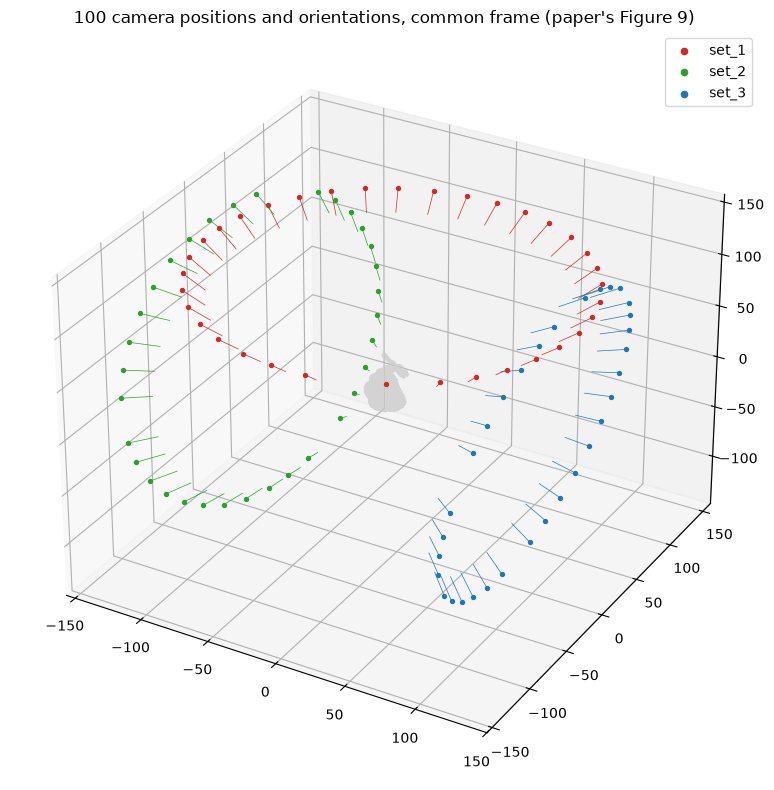

In [4]:
mesh_o3d = o3d.io.read_triangle_mesh(str(MESH_PLY))
verts = np.asarray(mesh_o3d.vertices)
sample = np.random.default_rng(0).choice(len(verts), size=min(20_000, len(verts)), replace=False)

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(verts[sample, 0], verts[sample, 1], verts[sample, 2], s=1, c="lightgray", alpha=0.3)

set_colors = {"set_1": "tab:red", "set_2": "tab:green", "set_3": "tab:blue"}
arrow_len = 20.0
for c in cameras:
    center, forward = tex.camera_center_and_forward(c["R"], c["t"])
    color = set_colors[c["set"]]
    ax.scatter(*center, s=8, c=color)
    tip = center + arrow_len * forward
    ax.plot(*zip(center, tip), c=color, linewidth=0.5)

for name, color in set_colors.items():
    ax.scatter([], [], [], c=color, label=name)  # legend handles only
ax.legend()
ax.set_title(f"{len(cameras)} camera positions and orientations, common frame (paper's Figure 9)")
plt.tight_layout()
plt.show()

## Sanity check - do the repositioned cameras actually look at the object?

Not a paper-specified step, but the cheapest possible check that `flip_z_camera_pose` and
`compose_with_registration` landed the cameras somewhere sensible: the angle between each
camera's look direction and the direction from that camera to the mesh's own centroid should
be small. It was ~173&deg; (facing almost exactly away from the object) before
`flip_z_camera_pose` was corrected to compose `R` with the z-flip on the right rather than the
left - see `utils/texturing.py`'s docstring.

In [5]:
centroid = verts.mean(axis=0)
print(f"mesh centroid: {centroid.round(2)}")

for name in SET_NAMES:
    angles = []
    for c in cameras:
        if c["set"] != name:
            continue
        center, forward = tex.camera_center_and_forward(c["R"], c["t"])
        to_centroid = centroid - center
        to_centroid /= np.linalg.norm(to_centroid)
        angles.append(np.degrees(np.arccos(np.clip(forward @ to_centroid, -1, 1))))
    angles = np.array(angles)
    print(f"{name}: look-direction vs. centroid - mean {angles.mean():.1f} deg, max {angles.max():.1f} deg")

mesh centroid: [-5.9  -4.81 18.92]
set_1: look-direction vs. centroid - mean 8.7 deg, max 9.7 deg
set_2: look-direction vs. centroid - mean 6.4 deg, max 6.5 deg
set_3: look-direction vs. centroid - mean 6.3 deg, max 6.6 deg


## Step 2 - Undistort photographs

`undistort_photo` removes Step 4's calibrated `SIMPLE_RADIAL` lens distortion - vertices get
projected with a plain pinhole model, so the photo sampled at that projection needs to already
be undistorted to match.

In [6]:
for c in cameras:
    png = tex.undistort_photo(c["pose"], RASTER_DIR)
    c["image"] = tex.load_rgb(png)
    c["focal_px"] = c["pose"].focal_px
    c["principal_point"] = c["pose"].principal_point

print(f"undistorted {len(cameras)} photos -> {RASTER_DIR}")

undistorted 100 photos -> /home/gnoceras/ScanningTable/outputs/textured/rasters


## Step 3 - Texture the mesh

Project every camera's undistorted photo onto the mesh and paint each vertex with the
occlusion-aware, multi-view-blended result. Any vertex no registered camera could see keeps its
existing colour (interpolated from Step 7's merged point cloud during Step 8's Poisson
reconstruction) rather than being left uncoloured.

In [7]:
mesh_o3d.compute_vertex_normals()
photo_colors, has_photo_color = tex.texture_mesh_vertex_colors(mesh_o3d, cameras)

original_colors = np.asarray(mesh_o3d.vertex_colors) * 255.0
final_colors = np.where(has_photo_color[:, None], photo_colors, original_colors)
mesh_o3d.vertex_colors = o3d.utility.Vector3dVector(np.clip(final_colors, 0, 255) / 255.0)

o3d.io.write_triangle_mesh(str(OUT_MESH_PLY), mesh_o3d)

print(f"{has_photo_color.sum():,} / {len(has_photo_color):,} vertices "
      f"({has_photo_color.mean():.1%}) coloured directly from a registered photo")
print(f"remaining {(~has_photo_color).sum():,} vertices kept their Step 8 point-cloud colour")
print(f"wrote {OUT_MESH_PLY}")

152,090 / 196,419 vertices (77.4%) coloured directly from a registered photo
remaining 44,329 vertices kept their Step 8 point-cloud colour
wrote /home/gnoceras/ScanningTable/outputs/textured/textured_vertex_colors.ply


## Preview

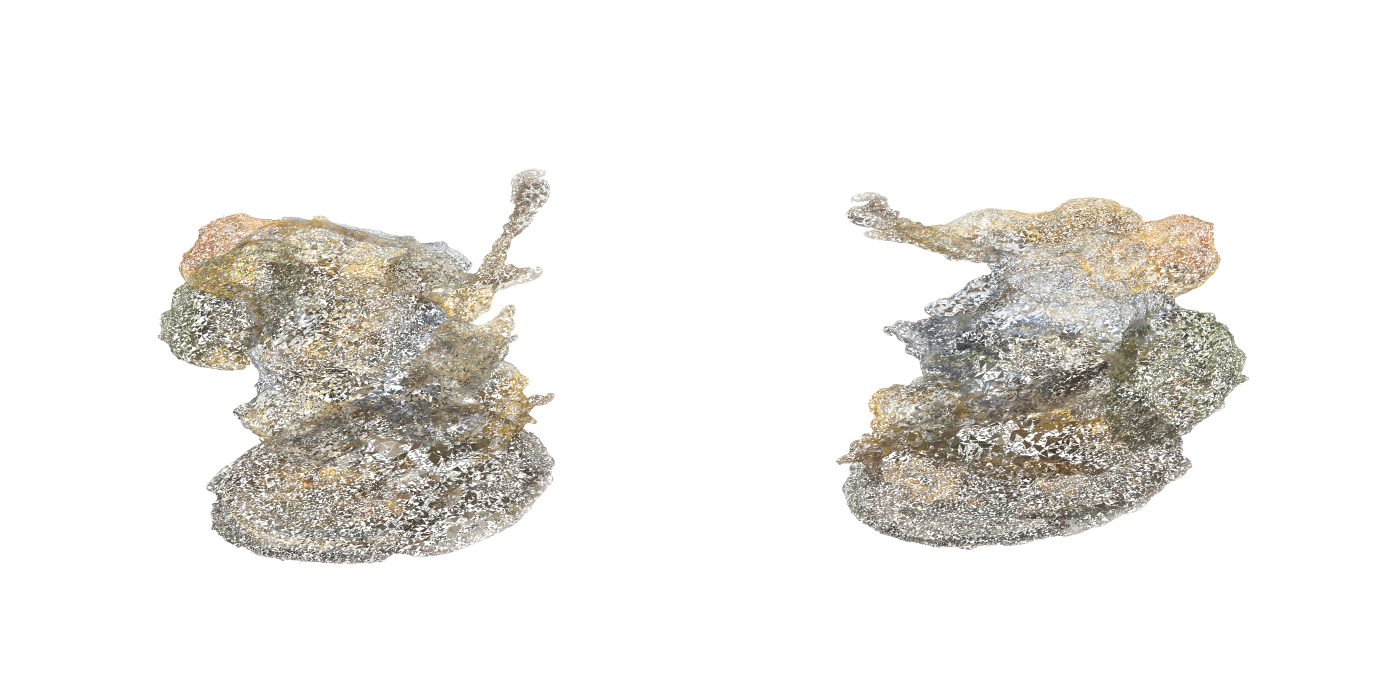

In [8]:
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

verts = np.asarray(mesh_o3d.vertices)
faces = np.asarray(mesh_o3d.triangles)
vcolors = np.asarray(mesh_o3d.vertex_colors)

rng = np.random.default_rng(0)
sample_faces = rng.choice(len(faces), size=min(150_000, len(faces)), replace=False)
faces_s = faces[sample_faces]

fig = plt.figure(figsize=(14, 7))
for i, (azim, elev) in enumerate([(30, 20), (210, 20)]):
    ax = fig.add_subplot(1, 2, i + 1, projection="3d")
    pc = Poly3DCollection(verts[faces_s], facecolor=vcolors[faces_s].mean(axis=1), edgecolor="none")
    ax.add_collection3d(pc)
    ax.set_xlim(verts[:, 0].min(), verts[:, 0].max())
    ax.set_ylim(verts[:, 1].min(), verts[:, 1].max())
    ax.set_zlim(verts[:, 2].min(), verts[:, 2].max())
    ax.view_init(elev=elev, azim=azim)
    ax.set_axis_off()
plt.tight_layout()
plt.show()

Note the rough, spiky patches visible from some angles: that's Step 8's own Poisson
reconstruction (`outputs/mesh/mesh.ply`), not something this step introduces - rendering the
*untextured* mesh with its Step 7/8 point-cloud colours the same way shows the identical
roughness.

## Summary

In [9]:
print(f"mesh:              {MESH_PLY}")
print(f"sets:              {SET_NAMES}")
print(f"cameras used:      {len(cameras)}")
print(f"rasters:           {RASTER_DIR}")
print(f"vertex coverage:   {has_photo_color.mean():.1%} direct from photos, "
      f"{(~has_photo_color).mean():.1%} from Step 8's point cloud")
print(f"textured mesh:     {OUT_MESH_PLY}")

mesh:              /home/gnoceras/ScanningTable/outputs/mesh/mesh.ply
sets:              ['set_1', 'set_2', 'set_3']
cameras used:      100
rasters:           /home/gnoceras/ScanningTable/outputs/textured/rasters
vertex coverage:   77.4% direct from photos, 22.6% from Step 8's point cloud
textured mesh:     /home/gnoceras/ScanningTable/outputs/textured/textured_vertex_colors.ply
